In [ ]:
!pip install pandas numpy scikit-learn nltk

import pandas as pd
import numpy as np
import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
fake = pd.read_csv("/content/Fake.csv")
true = pd.read_csv("/content/True.csv")

In [ ]:
fake["label"] = 0   # Fake
true["label"] = 1   # Real

data = pd.concat([fake, true])
data = data.sample(frac=1).reset_index(drop=True)

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

data["text"] = data["text"].apply(clean_text)

In [ ]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9894209354120267
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4711
           1       0.99      0.99      0.99      4269

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
def predict_news(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    prediction = model.predict(vec)[0]

    if prediction == 1:
        return "Real News"
    else:
        return "Fake News"

# Try it
print(predict_news("Breaking: Government announces new policy for education reform"))

Fake News


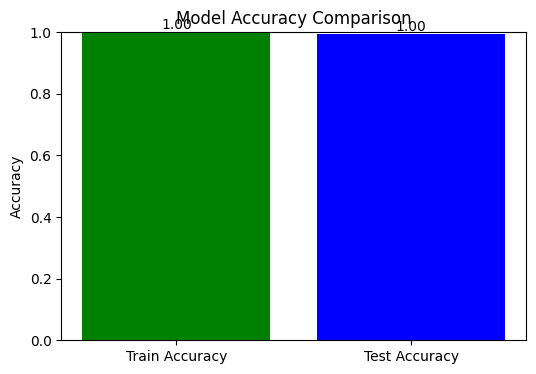

In [ ]:
import matplotlib.pyplot as plt

train_acc = model.score(X_train_vec, y_train)
test_acc = model.score(X_test_vec, y_test)

plt.figure(figsize=(6,4))
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['green','blue'])

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0,1)

for i, v in enumerate([train_acc, test_acc]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [ ]:
fake_samples = data[data['label'] == 0].head(2)
real_samples = data[data['label'] == 1].head(3)

samples = pd.concat([fake_samples, real_samples])

for i, row in samples.iterrows():
    text = row['text']
    actual = "Real" if row['label'] == 1 else "Fake"

    pred = predict_news(text)

    print("="*80)
    print("News:", text[:200], "...")  # show first 200 chars
    print("Actual:", actual)
    print("Predicted:", pred)

In [ ]:
data["content"] = data["title"] + " " + data["text"]

In [ ]:
data["content"] = data["content"].apply(clean_text)

In [ ]:
X = data["content"]
y = data["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
from sklearn.linear_model import PassiveAggressiveClassifier

model = PassiveAggressiveClassifier(max_iter=50)
model.fit(X_train_vec, y_train)

PassiveAggressiveClassifier(max_iter=50)

In [ ]:
print("Train Accuracy:", model.score(X_train_vec, y_train))
print("Test Accuracy:", model.score(X_test_vec, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.99543429844098


In [ ]:
print(predict_news("Government announces new education policy reform"))

Fake News


In [ ]:
true_news_samples = [
    "The government has announced a new policy to improve rural healthcare services across the country.",

    "Scientists at a leading university have developed a new method for early detection of cancer.",

    "The central bank has decided to keep interest rates unchanged after its latest meeting.",

    "Flood relief operations are underway after heavy rains affected several districts in the state.",

    "The stock market closed higher today as tech companies reported strong quarterly earnings."
]

for news in true_news_samples:
    prediction = predict_news(news)

    print("News:", news)
    print("Prediction:", prediction)
    print("-"*60)

News: The government has announced a new policy to improve rural healthcare services across the country.
Prediction: Real News
------------------------------------------------------------
News: Scientists at a leading university have developed a new method for early detection of cancer.
Prediction: Fake News
------------------------------------------------------------
News: The central bank has decided to keep interest rates unchanged after its latest meeting.
Prediction: Real News
------------------------------------------------------------
News: Flood relief operations are underway after heavy rains affected several districts in the state.
Prediction: Fake News
------------------------------------------------------------
News: The stock market closed higher today as tech companies reported strong quarterly earnings.
Prediction: Real News
------------------------------------------------------------
